In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.datasets.simulated_data import pretraining_data_simulator, finetuning_simulator

# Visualize data generation

In [2]:
simulator_type = 'simulated_cpc'
sigma = 0.1
fs = 100
length = 1
if simulator_type == 'simulated_cpc':
    groups_of_dep_var = 2*[2]
    n_sources = [2,3]

elif simulator_type == 'simulated_multiview':
    n_sources = [5]
    groups_of_dep_var = [4]

simulator = pretraining_data_simulator(n_sources = n_sources, groups_of_dep_var=groups_of_dep_var, sigma = sigma, fs=fs, length=2*length, simulator_type=simulator_type, normalize_emission= True, seed = 0)
data, sources, em_matrix, freqs = simulator.generate(1000, return_sources=True, shuffle_variables=False)

In [3]:
n_points_to_plot = 1
data_to_plot = np.random.choice(data.shape[0], n_points_to_plot, replace = False)

In [4]:
def plot_data(data, sources, emission_matrices, data_to_plot, source_state = None, plotline = True):
    data_sources, vars, titles = [data, emission_matrices, sources], [data.shape[2], 1, sources.shape[2]], ['Data', 'Mixing matrix', 'Sources']

    fig = plt.figure(figsize=(15, len(data_to_plot)*5))
    subfigs = fig.subfigures(len(data_to_plot), 1, squeeze=False)

    for k in range(len(data_to_plot)):
        subfig_ax = subfigs[k][0].subfigures(1, 3)
        for i in range(3):
            ax = subfig_ax[i].subplots(vars[i], 1, squeeze=False)
            subfig_ax[i].suptitle('{}'.format(titles[i]))
            if i == 1:
                if len(data_sources[i].shape) > 2:
                    pos = ax[0][0].imshow(data_sources[i][data_to_plot[k], :, :].T, aspect = 'auto')
                else:
                    pos = ax[0][0].imshow(data_sources[i].T, aspect = 'auto')
                fig.colorbar(pos, ax=ax[0][0])
                continue
            for j in range(vars[i]):
                if source_state is not None:
                    if j == source_state and i == 2:
                        ax[j][0].plot(data_sources[i][data_to_plot[k], :, j], color='r')
                else:
                    ax[j][0].plot(data_sources[i][data_to_plot[k], :, j])
                # put vertical line at the middel of the time axis
                if plotline:
                    ax[j][0].axvline(x=data_sources[i].shape[1]/2, color='r', linestyle='--')
    plt.tight_layout()
    plt.show()

In [5]:
em_matrix

array([[0.43418691, 0.56581309, 0.        , 0.        ],
       [0.39610605, 0.60389395, 0.        , 0.        ],
       [0.        , 0.        , 0.59951013, 0.40048987],
       [0.        , 0.        , 0.44912526, 0.55087474],
       [0.        , 0.        , 0.47213411, 0.52786589]])

/var/folders/xl/fct1_y7d2tn5g3_7qcd7m89h0000gn/T/ipykernel_30617/2951437822.py:28: UserWarning: tight_layout not applied: number of rows in subplot specifications must be multiples of one another.
  plt.tight_layout()


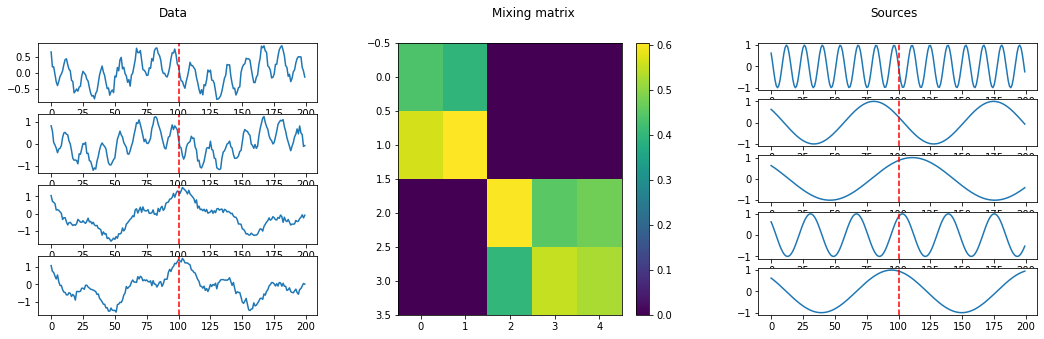

In [6]:
plot_data(data, sources, em_matrix, data_to_plot)


# Train model

In [6]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from src.datasets.datasets import SSL_dataset
from src.models.multiview import MPNN, AverageMPNN, conv1D_out_shape, pretrain
from src.models.losses import CMCloss
from torch.optim import Adam


In [7]:
class Multiview(nn.Module):
    def __init__(self, 
                 encoder,
                 out_dim = 64,
                 model_setup = 'MPNN',
                 pretraining_setup = 'multiview', 
                 num_message_passing_rounds = 2, 
                 feat_do = 0.1):
        super().__init__()
        self.out_dim = out_dim
        self.encoder = encoder
        self.pretraining_setup = pretraining_setup
        
        self.mpnn = model_setup in ['MPNN', 'average']
        if model_setup == 'MPNN':
            self.messagepassing = MPNN(out_dim, num_message_passing_rounds, feat_do)
        elif model_setup == 'average':
            self.messagepassing = AverageMPNN()
        
        self.projector = nn.Sequential(
            nn.AdaptiveAvgPool1d(5),
            nn.Flatten(),
            nn.Linear(out_dim*5, out_dim),
            nn.ReLU(),
            nn.Linear(out_dim, out_dim),
        )
        
    def remove_projection(self):
        self.projector = nn.Identity()
        
    def add_classifier(self, num_classes):
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Linear(self.out_dim, num_classes)
        )
    
    def get_view_ids(self, b, ch, device):
        view_id = torch.arange(b).unsqueeze(1).repeat(1, ch).view(-1).to(device)
        message_from = torch.arange(b*ch).unsqueeze(1).repeat(1, (ch-1)).view(-1).to(device)
        message_to = torch.arange(b*ch).view(b, ch).unsqueeze(1).repeat(1, ch, 1)
        idx = ~torch.eye(ch).view(1, ch, ch).repeat(b, 1, 1).bool()
        message_to = message_to[idx].view(-1).to(device)

        return view_id, message_from, message_to
    
    def train_step(self, x, loss_fn, device):
        if self.pretraining_setup == 'multiview':
            # partition the dataset into two views
            ch_size = np.random.randint(2, x.size(1)-1)
            random_channels = np.random.rand(x.size(1)).argpartition(x.size(1)-1)
            view_1_idx = random_channels[:ch_size] # randomly select ch_size channels per input
            view_2_idx = random_channels[ch_size:] # take the remaining as the second view
            view_1 = x[:, view_1_idx, :]
            view_2 = x[:, view_2_idx, :]
        elif self.pretraining_setup == 'cpc':
            # partition the x variables into two halves
            time_length = x.size(2)
            half = time_length // 2
            view_1 = x[:, :, :half]
            view_2 = x[:, :, half:]    

        if self.mpnn:
            out1 = self.forward(view_1)
            out2 = self.forward(view_2)

            out = torch.cat([out1.unsqueeze(1), out2.unsqueeze(1)], dim = 1)
        else:
            x = x.to(device)
            out = self.forward(x)

        loss = loss_fn(out)
        
        if isinstance(loss, tuple):
            return loss
        else:
            return loss, *[torch.tensor(0)]*2

    def forward(self, x, classify = False):
        b, ch, ts = x.shape
        x = x.view(b*ch, 1, ts)
        latents = self.encoder(x)

        if self.mpnn:
            view_id, message_from, message_to = self.get_view_ids(b, ch, latents.device)
            latents = self.messagepassing(view_id, message_from, message_to, latents, ch, b)
            latents = latents.permute(0, 2, 1)

        out = self.projector(latents)

        if not self.mpnn:
            out = out.view(b, ch, *out.shape[1:])

        if classify:
            return self.classifier(out)            
        else:
            return out

In [8]:
simulator_type = 'simulated_cpc'
pretraining_setup = 'multiview'

In [9]:
layers = 2
channels = [1, 8, 16, 32]
kernel_size = layers*[9]
stride = layers*[1]
padding = [kernel_size[i]//2 for i in range(layers)]
output_shape = conv1D_out_shape(200, layers*[2], layers*[2], layers*[0])
conv_layers = []
for i in range(layers):
    conv_layers.append(nn.Conv1d(channels[i], channels[i+1], kernel_size[i], stride[i], padding[i]))
    conv_layers.append(nn.BatchNorm1d(channels[i+1]))
    conv_layers.append(nn.MaxPool1d(2))
    conv_layers.append(nn.ReLU(inplace=False))
encoder = nn.Sequential(*conv_layers)
# mac mps
device = 'mps' if  torch.backends.mps.is_available() else 'cpu'
print('Training on: {}'.format(device))

model = Multiview(encoder, out_dim = channels[layers], model_setup = 'MPNN', pretraining_setup = pretraining_setup, num_message_passing_rounds = 1, feat_do = 0.1).to(device)
loss_fn = CMCloss(temperature = 0.5, criterion='contrastive').to(device)

Training on: mps


In [10]:
torch.mps.current_allocated_memory()/1e9
torch.autograd.set_detect_anomaly(True)

In [10]:
sigma = 0.1
fs = 100
length = 4
if simulator_type == 'simulated_cpc':
    groups_of_dep_var = 4*[1]
    n_sources = 4*[2]
elif simulator_type == 'simulated_multiview':
    n_sources = [2]
    groups_of_dep_var = [4]
simulator = pretraining_data_simulator(n_sources = n_sources, groups_of_dep_var=groups_of_dep_var, sigma = sigma, fs=fs, length=2*length, simulator_type=simulator_type, normalize_emission= True, seed = 0)

train_data = simulator.generate(1000, return_sources=False, shuffle_variables=True)
train_y = torch.zeros(train_data.shape[0])
val_data = simulator.generate(1000, return_sources=False, shuffle_variables=True)
val_y = torch.zeros(val_data.shape[0])
if pretraining_setup == 'multiview':
    train_data = train_data[:, :train_data.shape[1]//2, :]
    val_data = val_data[:, :val_data.shape[1]//2, :]
train_dataset = SSL_dataset(torch.from_numpy(train_data).transpose(1,2), train_y, standardize_channels=False)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataset = SSL_dataset(torch.from_numpy(val_data).transpose(1,2), val_y, standardize_channels=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [11]:
# get one sample
x, y = next(iter(train_loader))
temp = model.train_step(x.float().to(device), loss_fn, device)

In [12]:
optimizer = Adam(model.parameters(), lr=1e-4)
train_loss, val_loss = pretrain(model,
                                train_loader,
                                val_loader,
                                30,
                                optimizer,
                                device,
                                backup_path=None,
                                loss_fn = loss_fn,
                                log = False,
                                print_ = True)

KeyboardInterrupt: 

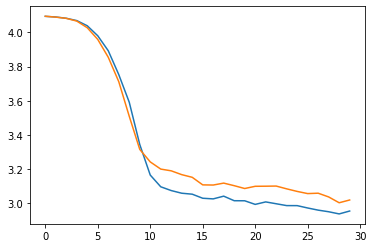

In [87]:
import matplotlib.pyplot as plt
plt.plot(train_loss)
plt.plot(val_loss)

In [25]:
sigma = 0.1
fs = 100
length = 4
simulator_type = 'simulated_cpc'
if simulator_type == 'simulated_cpc':
    groups_of_dep_var = 4*[1]
    n_sources = 4*[2]
elif simulator_type == 'simulated_multiview':
    n_sources = [4]
    groups_of_dep_var = [4]
simulator = finetuning_simulator(n_sources = n_sources, groups_of_dep_var=groups_of_dep_var, n_states = 2, n_state_sources=1, sigma = sigma, fs=fs, length=length, normalize_emission= True, seed = 0)
test_data, sources, emission, label = simulator.generate(1000, return_sources=True, random_freqs=True)
test_y = label
test_dataset = SSL_dataset(torch.from_numpy(test_data).transpose(1,2), test_y,standardize_channels=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [26]:
# get all latent variables and y from test set
model.eval()
latents = []
y = []
for x, y_ in test_loader:
    latents.append(model.forward(x.float().to(device)).detach().cpu().numpy())
    y.append(y_.detach().cpu().numpy())
latents = np.concatenate(latents)
y = np.concatenate(y)

In [27]:
# scatter plot of the latent variables
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=0)
z = tsne.fit_transform(latents)

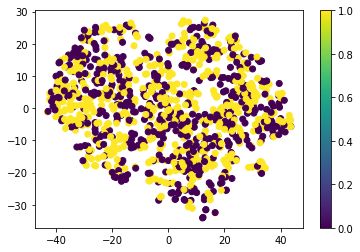

In [28]:
plt.scatter(z[:, 0], z[:, 1], c=y)
plt.colorbar()
plt.show()